# Exploration du Dataset — FakeNewsNet

Avant de toucher aux modèles, on regarde d'abord ce qu'on a comme données.  
L'objectif c'est de comprendre la structure, les distributions et les particularités du dataset.

## Imports

In [1]:
import os
import sys
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
import nltk
from nltk.corpus import stopwords
from sklearn.feature_extraction.text import CountVectorizer

nltk.download('stopwords', quiet=True)

# pour pouvoir importer config.py depuis le dossier parent
sys.path.append(os.path.join(os.getcwd(), '..'))
import config

pd.set_option('display.max_colwidth', 100)
print('imports ok')

imports ok


---
## 1 — Chargement des données

Le dataset contient 4 fichiers CSV. Les labels ne sont pas dans les fichiers,  
ils sont encodés dans les noms de fichiers : `_fake_` → 0, `_real_` → 1.

In [2]:
frames = []

for key, filename in config.RAW_FILES.items():
    path = os.path.join(config.DATA_RAW_DIR, filename)
    temp = pd.read_csv(path)

    # on ajoute le label et la source manuellement
    temp['label']  = config.FILE_LABELS[key]
    temp['source'] = config.FILE_SOURCES[key]

    print(f'{filename} → {temp.shape[0]} lignes')
    frames.append(temp)

# fusion des 4 fichiers en un seul dataframe
df = pd.concat(frames, ignore_index=True)
print(f'\nDataset complet : {df.shape[0]} lignes, {df.shape[1]} colonnes')

BuzzFeed_fake_news_content.csv → 91 lignes
BuzzFeed_real_news_content.csv → 91 lignes
PolitiFact_fake_news_content.csv → 120 lignes
PolitiFact_real_news_content.csv → 120 lignes

Dataset complet : 422 lignes, 13 colonnes


---
## 2 — Premier regard sur les données

In [3]:
# les colonnes disponibles et leurs types
print(df.dtypes)

id                object
title             object
text              object
url               object
top_img           object
authors           object
source            object
publish_date      object
movies            object
images            object
canonical_link    object
meta_data         object
label              int64
dtype: object


In [4]:
# quelques lignes pour voir à quoi ressemble le dataset
df.head(5)

,id,title,text,url,top_img,authors,source,publish_date,movies,images,canonical_link,meta_data,label
0,Fake_1-Webpage,Proof The Mainstream Media Is Manipulating The Election By Taking Bill Clinton Out Of Context,I woke up this morning to find a variation of this headline splashed all over my news feed:\n\nB...,http://www.addictinginfo.org/2016/09/19/proof-the-mainstream-media-is-manipulating-the-election-...,http://addictinginfo.addictinginfoent.netdna-cdn.com/wp-content/uploads/2016/09/GettyImages-6056...,Wendy Gittleson,buzzfeed,{'$date': 1474243200000},NaN,"http://i.imgur.com/JeqZLhj.png,http://addictinginfo.addictinginfoent.netdna-cdn.com/wp-content/u...",http://addictinginfo.com/2016/09/19/proof-the-mainstream-media-is-manipulating-the-election-by-t...,"{""publisher"": ""Addicting Info | The Knowledge You Crave"", ""description"": ""These headlines are re...",0
1,Fake_10-Webpage,Charity: Clinton Foundation Distributed “Watered-Down” AIDS Drugs to Sub-Saharan Africa – Eagle ...,Former President Bill Clinton and his Clinton Health Access Initiative (CHAI) distributed “water...,http://eaglerising.com/36899/charity-clinton-foundation-distributed-watered-down-aids-drugs-to-s...,http://eaglerising.com/wp-content/uploads/2016/09/aids.jpg,View All Posts,buzzfeed,{'$date': 1474416521000},NaN,"http://constitution.com/wp-content/uploads/2017/08/confederatemonument_poll_pop.jpg,http://2lv0h...",http://eaglerising.com/36899/charity-clinton-foundation-distributed-watered-down-aids-drugs-to-s...,"{""description"": ""The possibility that CHAI distributed adulterated and diluted AIDS drugs to Thi...",0
2,Fake_11-Webpage,A Hillary Clinton Administration May be Entirely Run by a FIGUREHEAD – Eagle Rising,After collapsing just before trying to step into her van after being removed from the 9-11 cerem...,http://eaglerising.com/36880/a-hillary-clinton-administration-may-be-entirely-run-by-a-figurehead/,http://eaglerising.com/wp-content/uploads/2016/09/administration.jpg,"View All Posts,Tony Elliott",buzzfeed,{'$date': 1474416638000},NaN,"http://constitution.com/wp-content/uploads/2017/08/confederatemonument_poll_pop.jpg,http://2lv0h...",http://eaglerising.com/36880/a-hillary-clinton-administration-may-be-entirely-run-by-a-figurehead/,"{""description"": ""Hillary Clinton may be the first Administration in US history where she is only...",0
3,Fake_12-Webpage,Trump’s Latest Campaign Promise May Be His Most Horrible One Yet,"Donald Trump is, well, deplorable. He’s suggested building a wall to keep invading hordes of bro...",http://www.addictinginfo.org/2016/09/19/trumps-latest-campaign-promise-may-be-his-most-horrible-...,http://addictinginfo.addictinginfoent.netdna-cdn.com/wp-content/uploads/2016/09/Untitled-1-Recov...,John Prager,buzzfeed,{'$date': 1474243200000},NaN,"http://i.imgur.com/JeqZLhj.png,http://2.gravatar.com/avatar/896e3249030ff74276709a1914c25ea3?s=7...",http://addictinginfo.com/2016/09/19/trumps-latest-campaign-promise-may-be-his-most-horrible-one-...,"{""publisher"": ""Addicting Info | The Knowledge You Crave"", ""description"": ""If Trump becomes Presi...",0
4,Fake_13-Webpage,Website is Down For Maintenance,Website is Down For Maintenance,http://www.proudcons.com/clinton-foundation-caught-in-their-most-disturbing-scheme-yet-countless...,NaN,NaN,buzzfeed,NaN,NaN,NaN,NaN,"{""og"": {""url"": ""http://www.proudcons.com"", ""type"": ""Maintenance"", ""site_name"": ""The Proud Conser...",0


In [5]:
# statistiques de base
df.describe()

,label
count,422.000000
mean,0.500000
std,0.500593
min,0.000000
25%,0.000000
50%,0.500000
75%,1.000000
max,1.000000


---
## 3 — Valeurs manquantes

In [6]:
# nombre et pourcentage de valeurs manquantes par colonne
missing = pd.DataFrame({
    'manquants'  : df.isnull().sum(),
    'pourcentage': (df.isnull().sum() / len(df) * 100).round(2)
})

print(missing.sort_values('pourcentage', ascending=False))

                manquants  pourcentage
movies                383        90.76
publish_date          127        30.09
authors                67        15.88
canonical_link         22         5.21
top_img                14         3.32
images                 14         3.32
url                    12         2.84
id                      0         0.00
text                    0         0.00
title                   0         0.00
source                  0         0.00
meta_data               0         0.00
label                   0         0.00


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_16704\2705651248.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=cols_with_missing.index, y=cols_with_missing['pourcentage'], palette='Reds_d')


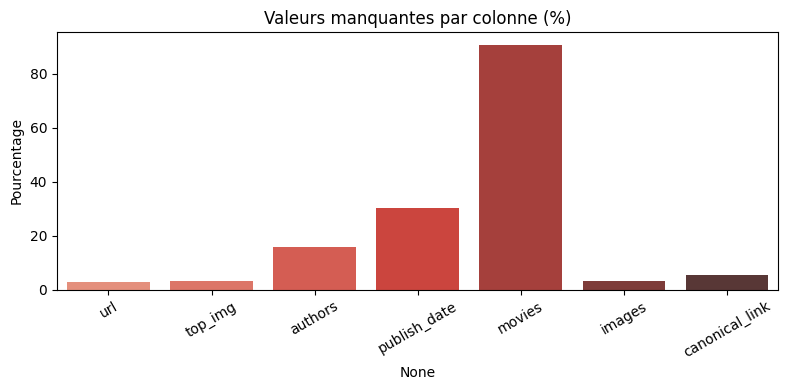

In [7]:
# visualisation des valeurs manquantes
cols_with_missing = missing[missing['manquants'] > 0]

if cols_with_missing.empty:
    print('Aucune valeur manquante !')
else:
    plt.figure(figsize=(8, 4))
    sns.barplot(x=cols_with_missing.index, y=cols_with_missing['pourcentage'], palette='Reds_d')
    plt.title('Valeurs manquantes par colonne (%)')
    plt.ylabel('Pourcentage')
    plt.xticks(rotation=30)
    plt.tight_layout()
    plt.savefig(os.path.join(config.RESULTS_DIR, 'missing_values.png'))
    plt.show()

---
## 4 — Distribution des classes

On vérifie si le dataset est équilibré entre fake et real.

In [8]:
# comptage par classe
counts = df['label'].value_counts().sort_index()

for label, count in counts.items():
    name = config.LABEL_NAMES[label]
    pct  = count / len(df) * 100
    print(f'{name} ({label}) : {count} articles ({pct:.1f}%)')

Fake (0) : 211 articles (50.0%)
Real (1) : 211 articles (50.0%)


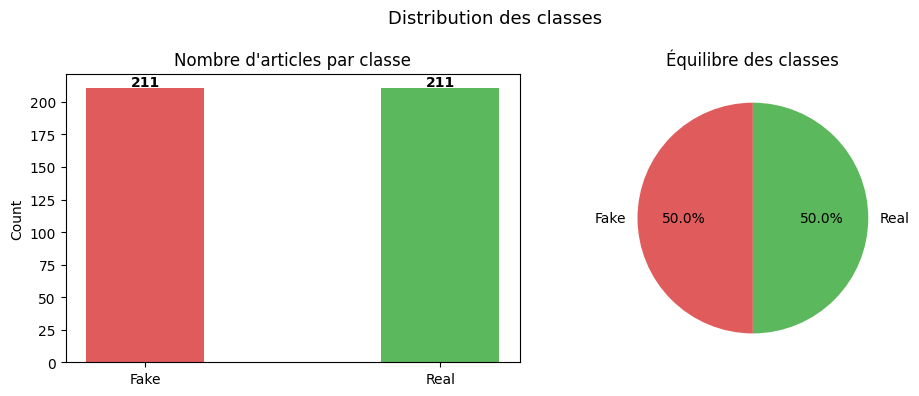

In [9]:
colors = ['#e05c5c', '#5cb85c']  # rouge pour fake, vert pour real

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# bar chart
labels_names = [config.LABEL_NAMES[i] for i in counts.index]
axes[0].bar(labels_names, counts.values, color=colors, width=0.4)
axes[0].set_title('Nombre d\'articles par classe')
axes[0].set_ylabel('Count')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 1, str(v), ha='center', fontweight='bold')

# pie chart
axes[1].pie(
    counts.values,
    labels=labels_names,
    colors=colors,
    autopct='%1.1f%%',
    startangle=90
)
axes[1].set_title('Équilibre des classes')

plt.suptitle('Distribution des classes', fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(config.RESULTS_DIR, 'class_distribution.png'))
plt.show()

---
## 5 — Distribution par source

BuzzFeed et PolitiFact ont peut-être des caractéristiques différentes.  
On regarde la distribution fake/real dans chacune des deux sources.

In [10]:
# tableau croisé source × label
cross = pd.crosstab(df['source'], df['label'])
cross.columns = [config.LABEL_NAMES[c] for c in cross.columns]
print(cross)

            Fake  Real
source                
buzzfeed      91    91
politifact   120   120


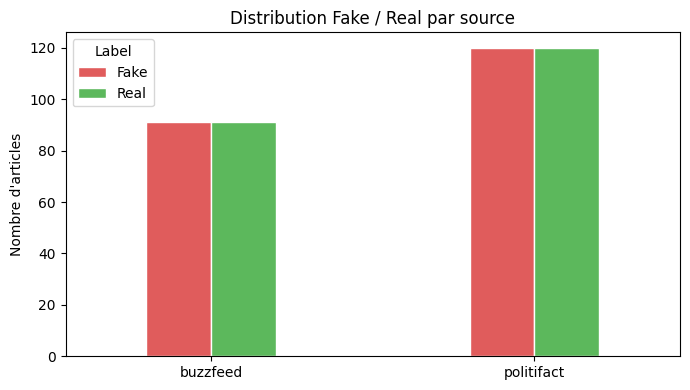

In [11]:
# visualisation
cross.plot(kind='bar', color=colors, figsize=(7, 4), width=0.4, edgecolor='white')
plt.title('Distribution Fake / Real par source')
plt.xlabel('')
plt.ylabel('Nombre d\'articles')
plt.xticks(rotation=0)
plt.legend(title='Label')
plt.tight_layout()
plt.savefig(os.path.join(config.RESULTS_DIR, 'source_distribution.png'))
plt.show()

---
## 6 — Longueur des textes

On regarde combien de mots contiennent les titres et les articles.  
Ça va nous aider à choisir la bonne valeur pour `MAX_SEQUENCE_LENGTH`.

In [12]:
# calcul des longueurs en nombre de mots
df['titre_len'] = df['title'].fillna('').apply(lambda x: len(x.split()))
df['texte_len'] = df['text'].fillna('').apply(lambda x: len(x.split()))

print('--- Titre ---')
print(df['titre_len'].describe().round(1))

print('\n--- Corps du texte ---')
print(df['texte_len'].describe().round(1))

--- Titre ---
count    422.0
mean      10.9
std        3.7
min        3.0
25%        8.0
50%       10.0
75%       13.0
max       29.0
Name: titre_len, dtype: float64

--- Corps du texte ---
count     422.0
mean      593.8
std       679.6
min         5.0
25%       269.0
50%       394.0
75%       585.0
max      5459.0
Name: texte_len, dtype: float64


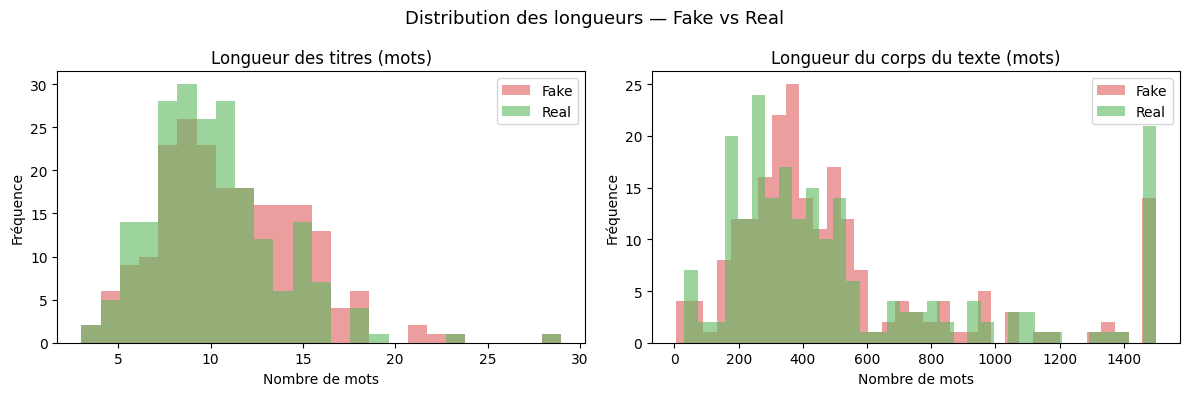

In [13]:
# histogrammes : fake vs real
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for label_val, label_name, color in zip([0, 1], ['Fake', 'Real'], colors):
    subset = df[df['label'] == label_val]

    axes[0].hist(subset['titre_len'], bins=25, alpha=0.6, label=label_name, color=color)
    axes[1].hist(subset['texte_len'].clip(upper=1500), bins=35, alpha=0.6, label=label_name, color=color)

axes[0].set_title('Longueur des titres (mots)')
axes[1].set_title('Longueur du corps du texte (mots)')

for ax in axes:
    ax.set_xlabel('Nombre de mots')
    ax.set_ylabel('Fréquence')
    ax.legend()

plt.suptitle('Distribution des longueurs — Fake vs Real', fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(config.RESULTS_DIR, 'text_lengths.png'))
plt.show()

---
## 7 — Nuages de mots

On génère un nuage de mots pour les titres des articles fake et real.  
C'est une bonne façon de voir si le vocabulaire est différent entre les deux classes.

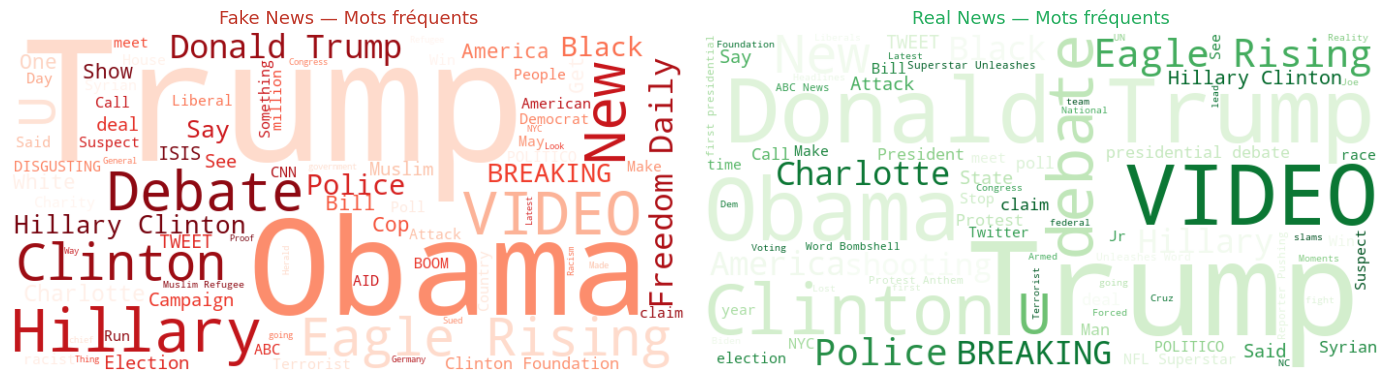

In [14]:
stop_words = set(stopwords.words('english'))

# on concatène tous les titres par classe
fake_titles = ' '.join(df[df['label'] == 0]['title'].dropna().values)
real_titles = ' '.join(df[df['label'] == 1]['title'].dropna().values)

wc_fake = WordCloud(width=700, height=350, background_color='white',
                    stopwords=stop_words, colormap='Reds',
                    max_words=80).generate(fake_titles)

wc_real = WordCloud(width=700, height=350, background_color='white',
                    stopwords=stop_words, colormap='Greens',
                    max_words=80).generate(real_titles)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].imshow(wc_fake, interpolation='bilinear')
axes[0].set_title('Fake News — Mots fréquents', color='#c0392b', fontsize=13)
axes[0].axis('off')

axes[1].imshow(wc_real, interpolation='bilinear')
axes[1].set_title('Real News — Mots fréquents', color='#27ae60', fontsize=13)
axes[1].axis('off')

plt.tight_layout()
plt.savefig(os.path.join(config.RESULTS_DIR, 'wordclouds.png'))
plt.show()

---
## 8 — N-grammes les plus fréquents

Les nuages de mots c'est bien visuellement, mais les n-grammes donnent plus d'infos.  
On regarde les unigrammes et bigrammes les plus fréquents pour chaque classe.

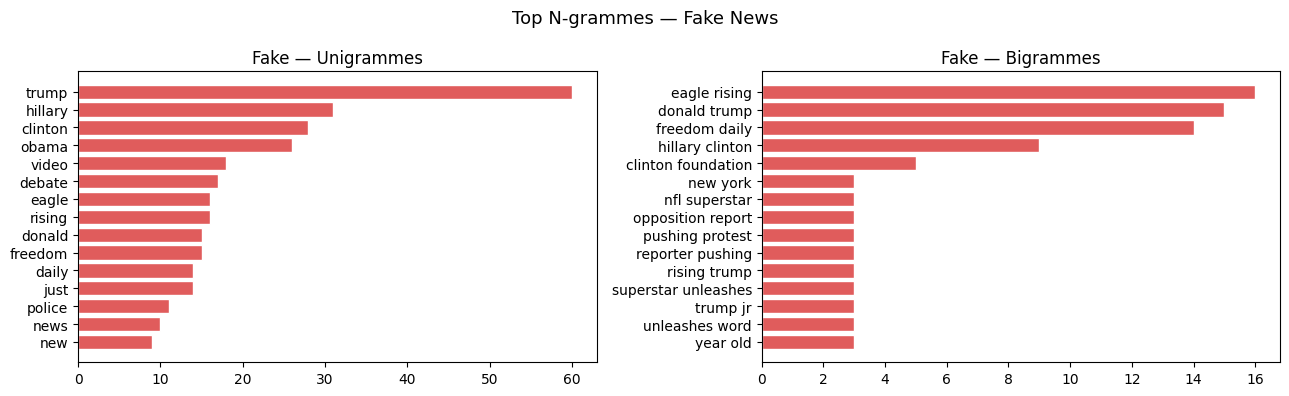

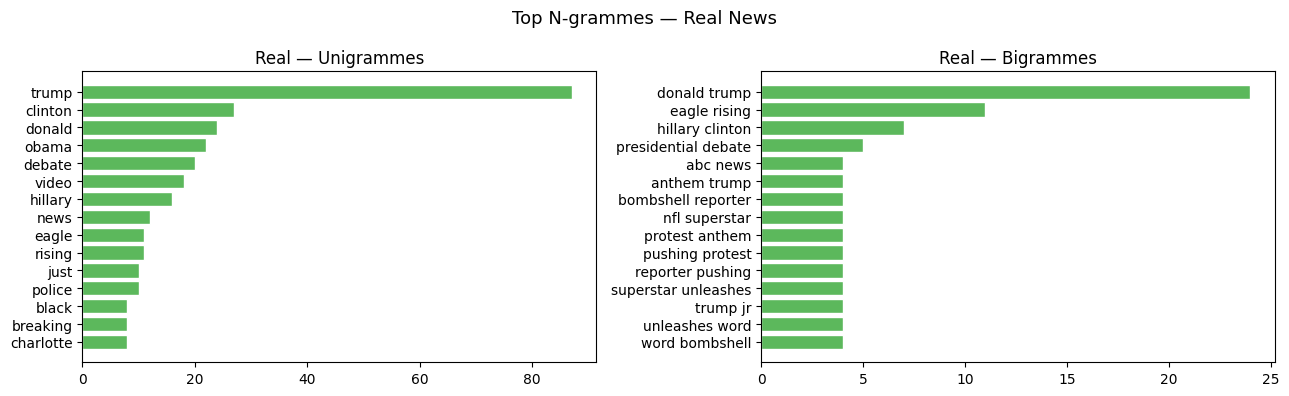

In [15]:
def top_ngrams(corpus, n, k=15):
    # extrait les k n-grammes les plus fréquents d'un corpus
    vec = CountVectorizer(ngram_range=(n, n), stop_words='english', max_features=k)
    vec.fit([corpus])
    bag = vec.transform([corpus])
    counts = zip(vec.get_feature_names_out(), bag.toarray()[0])
    return sorted(counts, key=lambda x: x[1], reverse=True)


for label_val, label_name, color in zip([0, 1], ['Fake', 'Real'], colors):
    corpus = ' '.join(df[df['label'] == label_val]['title'].dropna().values)

    fig, axes = plt.subplots(1, 2, figsize=(13, 4))

    for ax, n, title in zip(axes, [1, 2], ['Unigrammes', 'Bigrammes']):
        ngrams = top_ngrams(corpus, n=n)
        words, vals = zip(*ngrams)

        ax.barh(words, vals, color=color, edgecolor='white')
        ax.invert_yaxis()
        ax.set_title(f'{label_name} — {title}')

    plt.suptitle(f'Top N-grammes — {label_name} News', fontsize=13)
    plt.tight_layout()
    plt.savefig(os.path.join(config.RESULTS_DIR, f'ngrams_{label_name.lower()}.png'))
    plt.show()

---
## 9 — Exemples d'articles

On regarde quelques articles directement pour avoir une idée du contenu réel.

In [16]:
# 3 exemples de fake news
print('=' * 70)
print('FAKE NEWS')
print('=' * 70)

for _, row in df[df['label'] == 0][['title', 'text', 'source']].sample(3, random_state=42).iterrows():
    print(f'\nSource : {row["source"]}')
    print(f'Titre  : {row["title"]}')
    print(f'Texte  : {str(row["text"])[:250]}...')

print('\n' + '=' * 70)
print('REAL NEWS')
print('=' * 70)

# 3 exemples de real news
for _, row in df[df['label'] == 1][['title', 'text', 'source']].sample(3, random_state=42).iterrows():
    print(f'\nSource : {row["source"]}')
    print(f'Titre  : {row["title"]}')
    print(f'Texte  : {str(row["text"])[:250]}...')

FAKE NEWS

Source : buzzfeed
Titre  : DESPICABLE! Hillary Wants To Put Hero Cop Who Stopped Mall Terror Attack Out Of BUSINESS ⋆ Freedom Daily
Texte  : 5.2k SHARES Facebook Twitter

Jason Falconer, the NRA-certified firearms instructor and off-duty police officer, who shot the ISIS terrorist who stabbed eight people in St. Cloud, Minnesota, is someone that Hillary Clinton wants to put out of busines...

Source : politifact
Titre  : Debate breaks record as most-watched in U.S. history
Texte  : Monday night was the most-watched debate in American history.

Well over 80 million people tuned in to see Hillary Clinton and Donald Trump face off, setting a new record in the sixty year history of televised presidential debates.

According to Niel...

Source : politifact
Titre  : BREAKING: Toby Keith Forced To Cancel Show, I Didn’t Expect This
Texte  : Toby Keith has been forced to cancel his show in South Carolina and it was totally unexpected.

Toby Keith was scheduled to perform at the Flore

---
## 10 — Doublons

In [17]:
print(f'Lignes dupliquées       : {df.duplicated().sum()}')
print(f'Titres dupliqués        : {df["title"].duplicated().sum()}')
print(f'Corps de texte dupliqués: {df["text"].dropna().duplicated().sum()}')

Lignes dupliquées       : 0
Titres dupliqués        : 133
Corps de texte dupliqués: 133
